In [ ]:
library(Seurat)
library(SeuratData)
library(patchwork)
library(ggplot2)
library(purrr)
library(dplyr)
library(stringr)
library(tidyverse)
library(ggpubr)
library(RColorBrewer)

In [437]:
GCA_obj_subset <- readRDS("GCA_obj_subset_celltype.Rdata")

In [445]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
p_Main <- DimPlot(GCA_obj_subset, reduction = "umap",group.by="subcelltype",
                            label = TRUE,ncol=1,raster = TRUE,pt.size = 2,
                        #    cols = DiscretePalette(15,palette="alphabet2"),
                         )

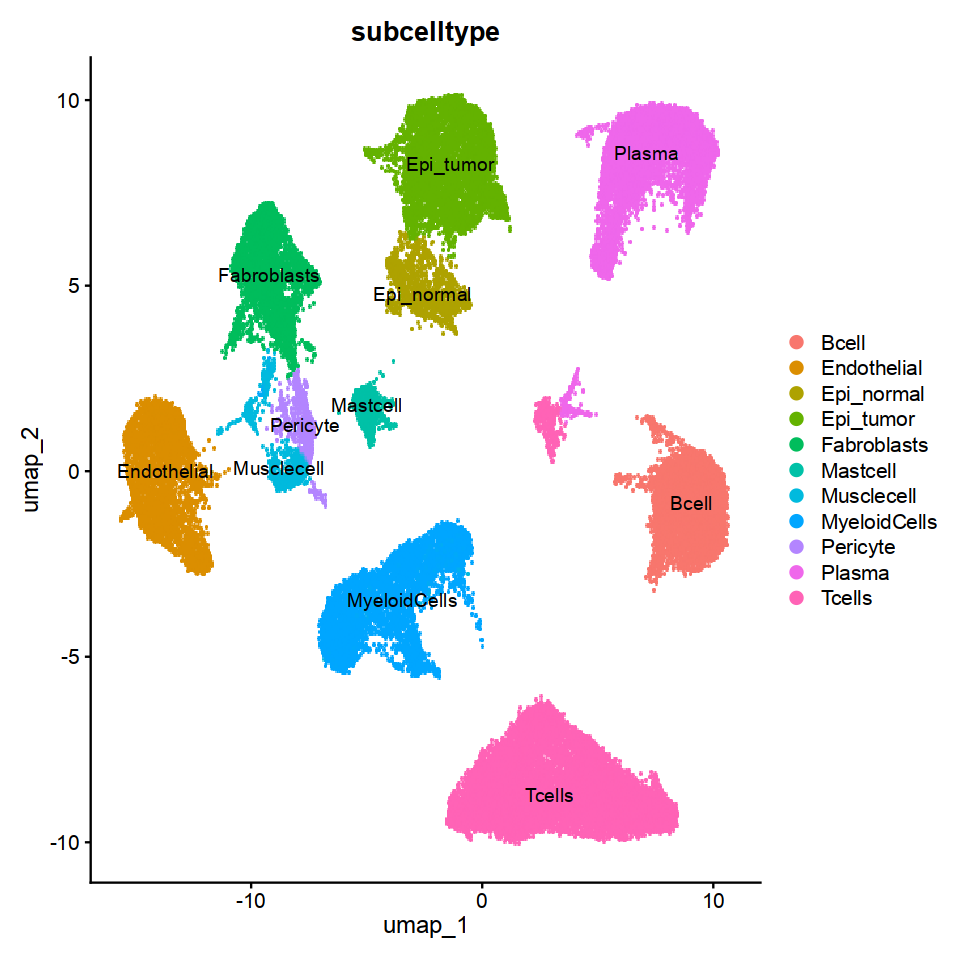

In [446]:
p_Main

In [12]:
#GCA_obj_subset@meta.data  %>%  filter(Maincelltype=='Phagocyte')  %>% 
#        rownames()  %>%  GCA_obj_subset[,.] -> GCA_obj_subset_Phagocyte

### move the muscle cells from myeloid to stromal

In [440]:
#GCA_obj_subset_Macrophage2@meta.data  %>%  filter(RNA_snn_res.0.5==7)  %>%  rownames() -> muscellcellnames

In [444]:
GCA_obj_subset@meta.data[muscellcellnames,'subcelltype'] <- 'Musclecell'

### move the T B cells from myeloid to T cells B cells

In [1056]:
GCA_obj_subset_Macrophage2@meta.data  %>%  filter(RNA_snn_res.0.5==5)  %>%  rownames() -> Tcellnames
GCA_obj_subset@meta.data[Tcellnames,'subcelltype'] <- 'Tcells'

In [473]:
#GCA_obj_subset_Macrophage2@meta.data  %>%  filter(RNA_snn_res.0.5==6)  %>%  rownames() -> Bcellnames
GCA_obj_subset@meta.data[Bcellnames,'subcelltype'] <- 'Bcell'

In [501]:
GCA_obj_subset_Macrophage2@meta.data  %>%  filter(RNA_snn_res.0.5==9|RNA_snn_res.0.5==8)  %>%  rownames() -> Plasmanames

In [502]:
GCA_obj_subset_Macrophage2@meta.data  %>%  filter(RNA_snn_res.0.5==10)  %>%  rownames() -> Tcellnames2
GCA_obj_subset@meta.data[Plasmanames,'subcelltype'] <- 'Plasma'

In [ ]:
GCA_obj_subset@meta.data[Tcellnames2,'subcelltype'] <- 'Tcells'

### excluding cells

In [1135]:
GCA_obj_subset_Tcell2@meta.data  %>%  filter(RNA_snn_res.0.5==10)  %>%  rownames() -> Monocytes_name_forexclue
GCA_obj_subset_Tcell2@meta.data  %>%  filter(RNA_snn_res.0.5==11)  %>%  rownames() -> Bcell_name2_forexclue

In [1143]:
length(Monocytes_name_forexclue)

[1] 299

In [1144]:
length(Bcell_name2_forexclue)

[1] 235

In [1147]:
GCA_obj_subset

An object of class Seurat 
36601 features across 47446 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap

In [1150]:
GCA_obj_subset@meta.data  %>% rownames()  %>% setdiff(c(Monocytes_name_forexclue,Bcell_name2_forexclue))  %>% GCA_obj_subset[,.] -> GCA_obj_subset_excludecells

In [1151]:
GCA_obj_subset_excludecells

An object of class Seurat 
36601 features across 46912 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap

In [1152]:
saveRDS(file = "GCA_obj_subset_celltype.Rdata",object = GCA_obj_subset_excludecells)

In [5]:
GCA_obj_subset_excludecells <- readRDS('GCA_obj_subset_celltype.Rdata')

In [1154]:
#GCA_obj_subset_Tcell2@meta.data  %>%  filter(RNA_snn_res.0.5==10)  %>%  rownames() -> Macrophagesname

In [1153]:
#GCA_obj_subset@meta.data$subcelltype  %>% unique()

In [841]:
GCA_obj_subset@meta.data[Monocytes_name,'subcelltype'] <- 'MyeloidCells'
GCA_obj_subset@meta.data[Bcell_name2,'subcelltype'] <- 'Bcell'

In [842]:
GCA_obj_subset@meta.data[Macrophagesname,'subcelltype'] <- 'MyeloidCells'

### extract the myeloid and T cells

In [475]:
GCA_obj_subset@meta.data$subcelltype  %>%  unique()

[1] "Tcells"       "Endothelial"  "Plasma"       "MyeloidCells" "Bcell"       
 [6] "Musclecell"   "Epi_tumor"    "Mastcell"     "Fabroblasts"  "Pericyte"    
[11] "Epi_normal"

In [1084]:
GCA_obj_subset_excludecells@meta.data  %>%  filter(subcelltype=='MyeloidCells')%>% 
        rownames()  %>%  GCA_obj_subset[,.] -> GCA_obj_subset_Macrophage

In [1155]:
GCA_obj_subset_excludecells@meta.data  %>% filter(subcelltype=='Tcells') %>% 
     rownames()  %>%  GCA_obj_subset[,.] -> GCA_obj_subset_Tcell

###  re-clustering for macrophage

In [ ]:
GCA_obj_subset_Macrophage[["RNA"]] <- split(GCA_obj_subset_Macrophage[["RNA"]],
                                           f = GCA_obj_subset_Macrophage$sample)

In [ ]:
GCA_obj_subset_Macrophage <- NormalizeData(GCA_obj_subset_Macrophage, normalization.method = "LogNormalize", 
                                           scale.factor = 10000)

In [ ]:
all.genes <- rownames(GCA_obj_subset_Macrophage)
GCA_obj_subset_Macrophage <- FindVariableFeatures(GCA_obj_subset_Macrophage, selection.method = "vst", 
                                                  nfeatures = 2000)
GCA_obj_subset_Macrophage <- ScaleData(GCA_obj_subset_Macrophage, features = all.genes)
GCA_obj_subset_Macrophage <- RunPCA(GCA_obj_subset_Macrophage, features = 
                                    VariableFeatures(object = GCA_obj_subset_Macrophage))

In [1088]:
GCA_obj_subset_Macrophage2 <- IntegrateLayers(object = GCA_obj_subset_Macrophage, method = CCAIntegration, orig.reduction = "pca",
                        new.reduction = "integrated.cca",verbose = FALSE)

In [1089]:
# re-join layers after integration
GCA_obj_subset_Macrophage2[["RNA"]] <- JoinLayers(GCA_obj_subset_Macrophage2[["RNA"]])

In [ ]:
GCA_obj_subset_Macrophage2 <- FindNeighbors(GCA_obj_subset_Macrophage2, dims = 1:30,reduction = "integrated.cca")

In [ ]:
GCA_obj_subset_Macrophage2 <- FindClusters(GCA_obj_subset_Macrophage2, resolution = 0.5)

In [ ]:
GCA_obj_subset_Macrophage2 <- RunUMAP(GCA_obj_subset_Macrophage2, dims = 1:30,reduction = "integrated.cca")

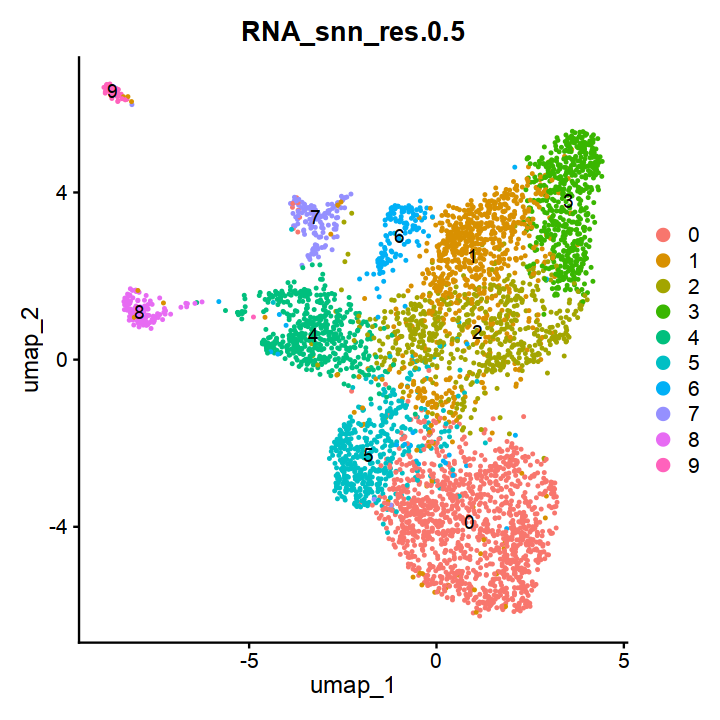

In [1094]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(GCA_obj_subset_Macrophage2, reduction = "umap", label = TRUE,group.by ="RNA_snn_res.0.5" )

In [1122]:
genes <- c( 'GPNMB', 'APOC1', 'CD9',  ## macrophageM1
            'C1QB', 'C1QC', 'C1QA', ##macrophage M2
            'VCAN', 'EREG', 'FCN1', ### Monocytes
            'CD1C', 'CD1E','FLT3',## Dendritic   
            'FCGR3B', 'CXCL8','NAMPT' ## Neutrophils
          )

In [1123]:
GCA_obj_subset_Macrophage2@meta.data$newtypes  <- factor(GCA_obj_subset_Macrophage2@meta.data$newtypes,
                                                         levels = c('Neutrophils','DendriticCells','Monocytes',
                                                                   'MacrophageM2','MacrophageM1'))

In [1124]:
Idents(GCA_obj_subset_Macrophage2) <- 'newtypes'

options(repr.plot.height=4,repr.plot.width=8)
p_myloied_markergenes <- DotPlot(GCA_obj_subset_Macrophage2, features = genes) + RotatedAxis()

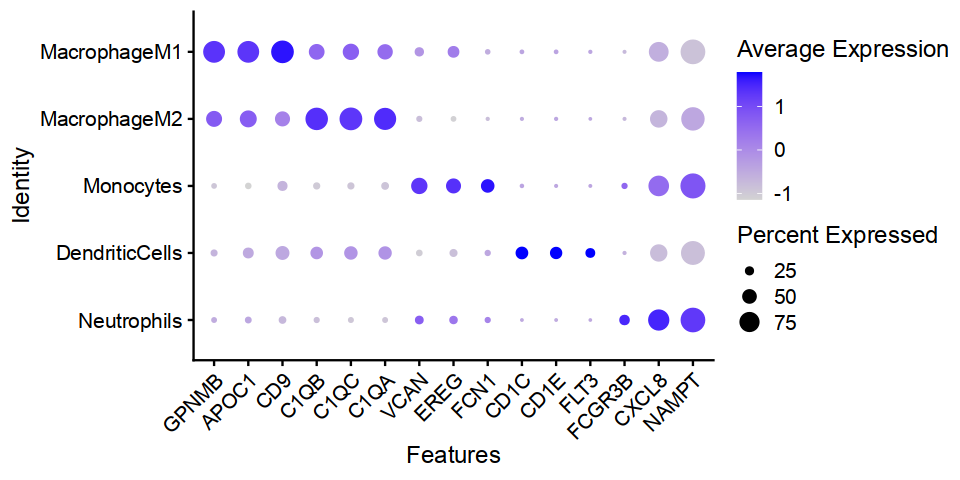

In [1128]:
p_myloied_markergenes

In [1129]:
ggsave(filename = "Myeloid_markergenes.pdf",plot =p_myloied_markergenes ,width = 8,height = 4)

In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
GCA_obj_subset_Macrophage2.markers <- FindAllMarkers(GCA_obj_subset_Macrophage2, only.pos = TRUE)

In [1217]:
GCA_obj_subset_Macrophage2

An object of class Seurat 
36601 features across 4512 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap

In [1119]:
GCA_obj_subset_Macrophage2.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) -> markers

In [ ]:
for(i in 0:9){
    markers  %>% filter(cluster==i)  %>% .[,'gene',drop=T] %>% head(n=20) -> genes
    cat("Cluster",i,':\t',genes,'\n')
}

In [1100]:
GCA_obj_subset_Macrophage2@meta.data  %>% mutate(newtypes=case_when(RNA_snn_res.0.5==0 ~ 'MacrophageM2',
                                                                  RNA_snn_res.0.5==1 ~ 'Neutrophils',
                                                                  RNA_snn_res.0.5==2 ~ 'Monocytes',
                                                                  RNA_snn_res.0.5==3 ~ 'Monocytes',
                                                                  RNA_snn_res.0.5==4 ~ 'DendriticCells',
                                                                  RNA_snn_res.0.5==5 ~ 'MacrophageM1',
                                                                  RNA_snn_res.0.5==6 ~ 'Neutrophils',
                                                                  RNA_snn_res.0.5==7 ~ 'DendriticCells',
                                                                  RNA_snn_res.0.5==8 ~ 'DendriticCells',
                                                                   RNA_snn_res.0.5==9 ~ 'DendriticCells')) -> GCA_obj_subset_Macrophage2@meta.data

In [6]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
options(repr.plot.height=6,repr.plot.width=8)
p_celltype <- DimPlot(GCA_obj_subset_Macrophage2, reduction = "umap",label = TRUE,group.by = 'newtypes',
                     cols = colorRampPalette(brewer.pal(10, "Spectral"))(6))

ERROR: Error in Cells(x = object, assay = DefaultAssay(object = object[[reduction]])): object 'GCA_obj_subset_Macrophage2' not found


In [7]:
p_celltype

ERROR: Error in eval(expr, envir, enclos): object 'p_celltype' not found


In [1132]:
saveRDS(GCA_obj_subset_Macrophage2,file = "GCA_obj_subset_Myloied.Rdata")

In [1133]:
ggsave(filename = "UMAP_MAC_Den_Mon.anno.pdf",plot =p_celltype ,width = 6,height = 6)

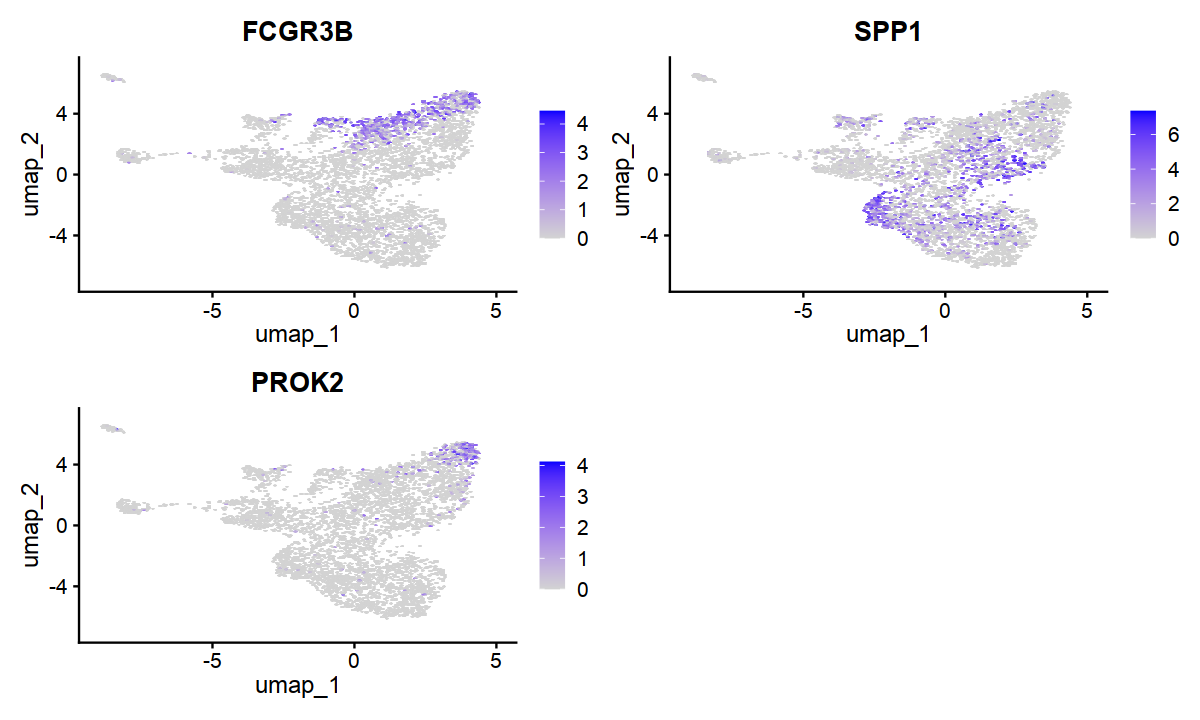

In [1134]:
options(repr.plot.height=6,repr.plot.width=10)
FeaturePlot(GCA_obj_subset_Macrophage2, features = c("FCGR3B","SPP1",'PROK2'), 
            raster = TRUE,pt.size = 3)

In [938]:
#ggsave(filename = "SPP1_exp_UMAP_MAC_Den_Mon.anno.pdf",plot =p_spp1 ,width = 6,height = 6)

###  re-clustering for Tcell

In [ ]:
GCA_obj_subset_Tcell[["RNA"]] <- split(GCA_obj_subset_Tcell[["RNA"]], 
                                           f = GCA_obj_subset_Tcell$sample)

In [ ]:
GCA_obj_subset_Tcell <- NormalizeData(GCA_obj_subset_Tcell, normalization.method = "LogNormalize", 
                                           scale.factor = 10000)

In [ ]:
all.genes <- rownames(GCA_obj_subset_Tcell)
GCA_obj_subset_Tcell <- FindVariableFeatures(GCA_obj_subset_Tcell, selection.method = "vst", 
                                                  nfeatures = 2000)
GCA_obj_subset_Tcell <- ScaleData(GCA_obj_subset_Tcell, features = all.genes)
GCA_obj_subset_Tcell <- RunPCA(GCA_obj_subset_Tcell, features = 
                                    VariableFeatures(object = GCA_obj_subset_Macrophage))

In [1159]:
GCA_obj_subset_Tcell2 <- IntegrateLayers(object = GCA_obj_subset_Tcell, method = CCAIntegration, orig.reduction = "pca",
                        new.reduction = "integrated.cca",verbose = FALSE)

In [1160]:
# re-join layers after integration
GCA_obj_subset_Tcell2[["RNA"]] <- JoinLayers(GCA_obj_subset_Tcell2[["RNA"]])

In [ ]:
GCA_obj_subset_Tcell2 <- FindNeighbors(GCA_obj_subset_Tcell2, dims = 1:30,reduction = "integrated.cca")
GCA_obj_subset_Tcell2 <- FindClusters(GCA_obj_subset_Tcell2, resolution = 0.5)
GCA_obj_subset_Tcell2 <- RunUMAP(GCA_obj_subset_Tcell2, dims = 1:30,reduction = "integrated.cca")

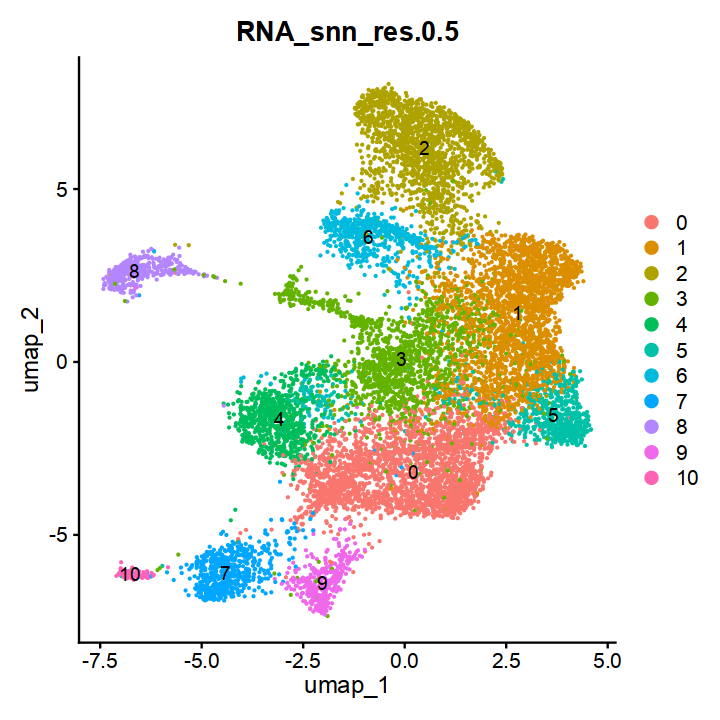

In [184]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(GCA_obj_subset_Tcell2, reduction = "umap",label = TRUE,group.by ="RNA_snn_res.0.5")

In [175]:
Idents(GCA_obj_subset_Tcell2) <- 'RNA_snn_res.0.5'

In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
GCA_obj_subset_Tcell2.markers <- FindAllMarkers(GCA_obj_subset_Tcell2, only.pos = TRUE)

In [178]:
GCA_obj_subset_Tcell2.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) -> markers

In [180]:
for(i in markers$cluster  %>% unique()){
    markers  %>% filter(cluster==i)  %>% .[,'gene',drop=T] %>% head(n=20) -> genes
    cat("Cluster",i,':\t',genes,'\n')
}

Cluster 0 :	 NKG7 CCL5 GZMK CCL4 GZMA CD8A CD8B GZMH AOAH CST7 KLRK1 GZMB ITM2C CCL4L2 LYAR ITGA1 SAMD3 DTHD1 IFNG LINC02446 
Cluster 1 :	 IL7R CCR7 ANK3 FAAH2 LTB TSHZ2 BACH2 CMTM8 ZBTB10 LEF1 GPR183 CD55 BTBD11 CD40LG TAF4B PASK SERINC5 SOCS3 SCML1 PRKCA 
Cluster 2 :	 IKZF2 LINC02694 TNFRSF4 TBC1D4 IL2RA FOXP3 RTKN2 IL1R1 TNFRSF18 LINC02099 IL1R2 CTLA4 AC013652.1 BATF PELI1 GK AC093865.1 ICOS F5 ICA1 
Cluster 3 :	 HIST1H2BG HIST1H2BD HIST1H3J IFNG-AS1 AL355075.4 AC022217.2 AC015849.1 C12orf42 AC104066.4 HIST1H2AG HIST2H2BF HIST1H4B AL353660.1 FGF13 AC078778.1 CSKMT AL109840.2 ANKRD36C ARHGAP35 BX284668.6 
Cluster 4 :	 MYO1E ENTPD1 CLNK SRGAP3 PDE7B ITGAE ATP8B4 DAPK2 LINC01871 ETV1 CXCL13 ZC3H12C CD8A TOX AL096794.1 RIN3 ADAMTS17 GFOD1 TNFRSF9 ZEB2 
Cluster 5 :	 SLC4A10 KLRB1 IL4I1 ADAM12 PLCB1 IL7R CEBPD IL23R ZBTB16 CCL20 AL136456.1 CA10 NCR3 RORA TMIGD2 ME1 CCR6 LINC01871 MYBL1 TNFSF13B 
Cluster 6 :	 GNG4 CD200 IL21 CXCL13 PDE7B AC004585.1 IGFL2 TOX2 KSR2 LHFPL6 TSHZ2 DRAIC PTPN13

In [278]:
genes <- c( 'CD8A', 'CD8B', 'GZMK',  ## CD8
            'IL7R', 'CD40LG','CD4', ##CD4 M2
            'IKZF2', 'TNFRSF4', 'IL2RA','FOXP3', ### Tregs
            'GNLY',  'TYROBP', 'FCER1G'  ## NK
          )

In [279]:
GCA_obj_subset_Tcell2@meta.data$newtypes2  <- factor(GCA_obj_subset_Tcell2@meta.data$newtypes2,
                                                         levels = c('CD8+ T',"CD8+ Low",'CD4+ T',
                                                                   'Tregs','Proliferating T','NK'))

In [280]:
Idents(GCA_obj_subset_Tcell2) <- 'newtypes2'

In [281]:
options(repr.plot.height=4,repr.plot.width=8)
p_Tcell_markergenes <- DotPlot(GCA_obj_subset_Tcell2, features = genes) + RotatedAxis()

In [282]:
GCA_obj_subset_Tcell2@meta.data  %>% filter(newtypes2 == 'CD8+ T')  -> CD8id

In [283]:
GCA_obj_subset_Tcell2@meta.data  %>% filter(newtypes2 == 'CD8+ Low')  -> CD8Lowid

In [284]:
saveRDS(object = CD8,file = "CD8.cellID.Rds")

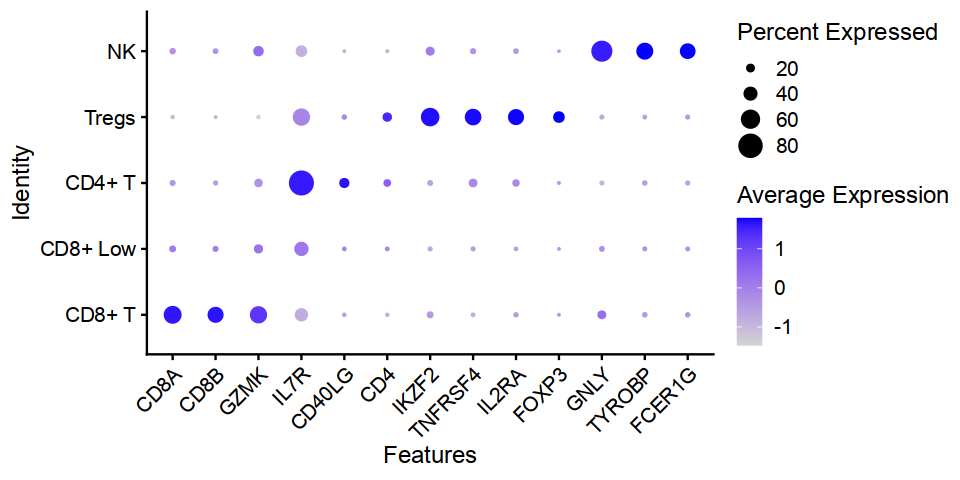

In [296]:
p_Tcell_markergenes

In [286]:
ggsave(filename = "Tcell_markergenes.pdf",plot =p_Tcell_markergenes ,width = 8,height = 4)

In [258]:
GCA_obj_subset_Tcell2@meta.data  %>% 
        mutate(newtypes2=case_when(RNA_snn_res.0.5==0 ~ 'CD8+ T',
                                  RNA_snn_res.0.5==1 ~ 'CD4+ T',
                                  RNA_snn_res.0.5==2 ~ 'Tregs',
                                  RNA_snn_res.0.5==3 ~ 'CD8+ Low',
                                  RNA_snn_res.0.5==4 ~ 'CD8+ T',
                                  RNA_snn_res.0.5==5 ~ 'CD4+ T',
                                  RNA_snn_res.0.5==6 ~ 'CD4+ T',
                                  RNA_snn_res.0.5==7 ~ 'NK',
                                  RNA_snn_res.0.5==8 ~ 'CD8+ T',
                                  RNA_snn_res.0.5==9 ~ 'NK',
                                  RNA_snn_res.0.5==10 ~ 'NK'
                                 )) -> GCA_obj_subset_Tcell2@meta.data

In [259]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
options(repr.plot.height=6,repr.plot.width=8)
p_tcells <- DimPlot(GCA_obj_subset_Tcell2, reduction = "umap",label = TRUE,group.by ="newtypes2",
                   cols = colorRampPalette(brewer.pal(10, "Spectral"))(6))

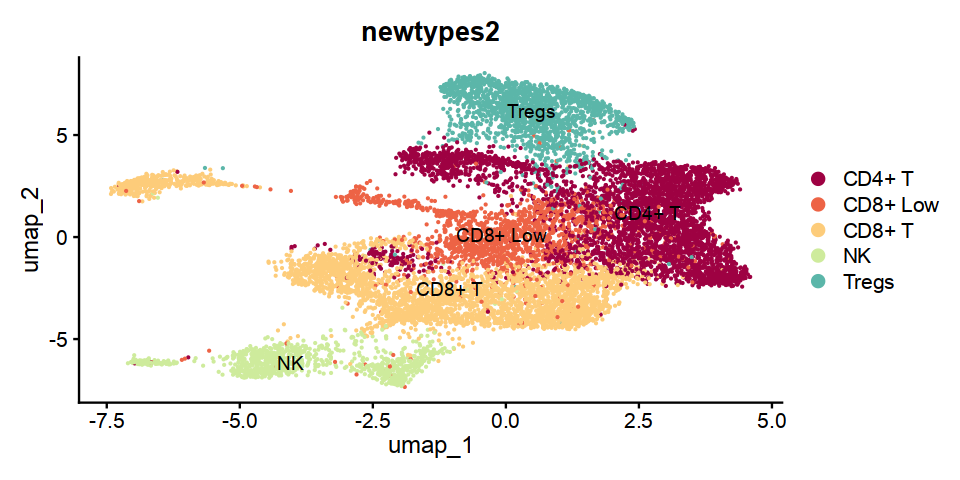

In [297]:
p_tcells

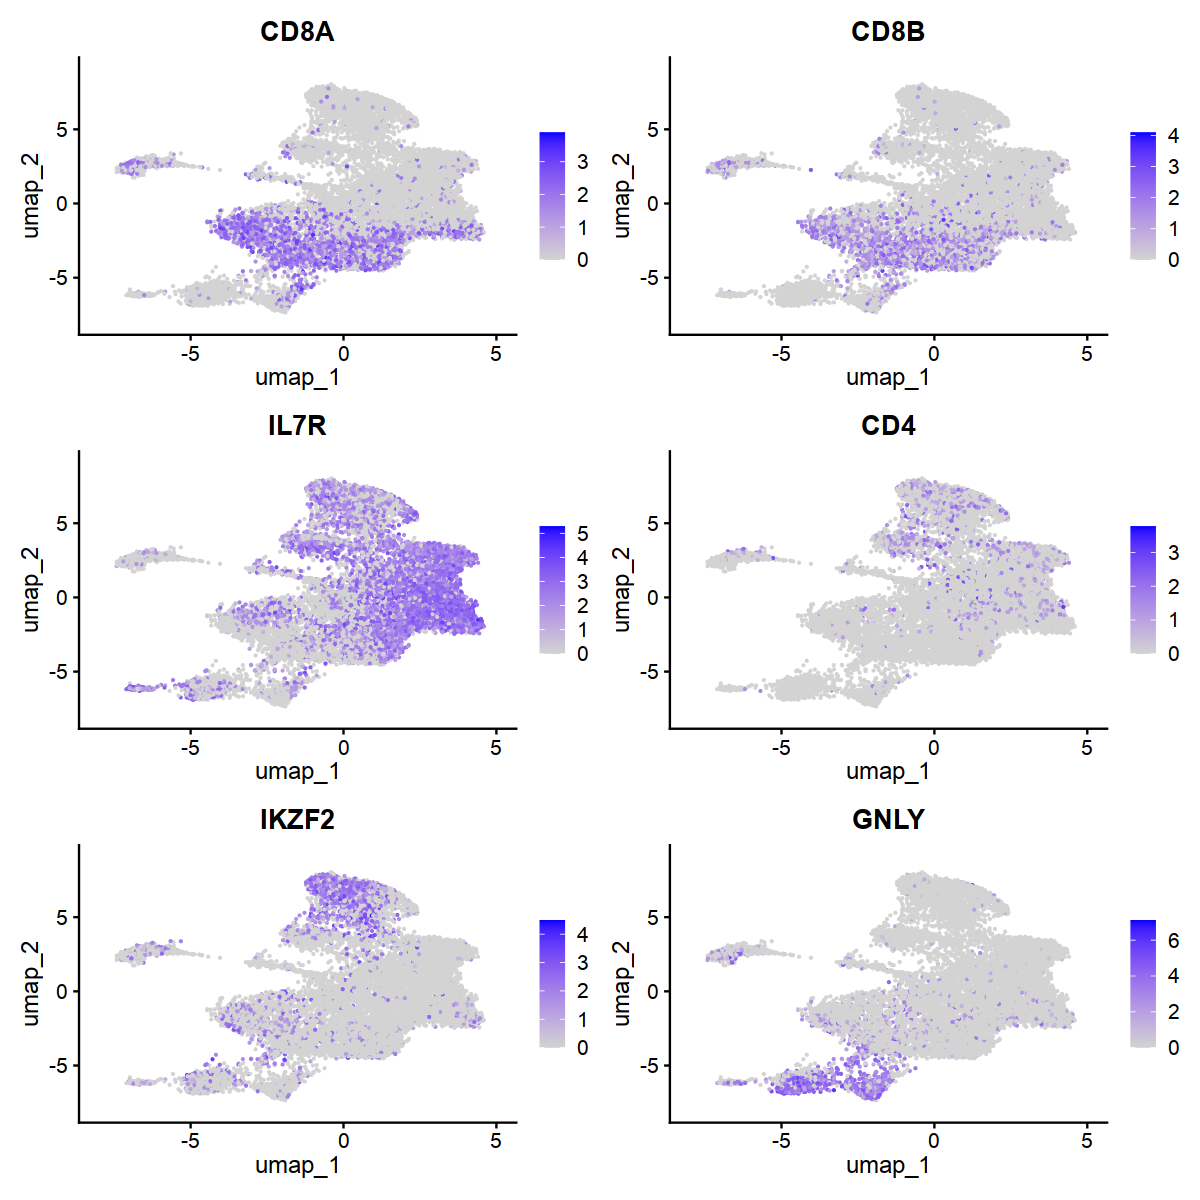

In [250]:
options(repr.plot.height=10,repr.plot.width=10)
FeaturePlot(GCA_obj_subset_Tcell2, features = c("CD8A","CD8B","IL7R","CD4",'IKZF2', 'GNLY'))

## p_tcells

In [271]:
ggsave(filename = "UMAP_Tcells.anno.pdf",plot =p_tcells ,width = 8,height = 6)

In [272]:
saveRDS(GCA_obj_subset_Tcell2,file = "GCA_obj_subset_Tcelltype2.Rdata")

In [62]:
GCA_obj_subset$celltype <- GCA_obj_subset$subcelltype

### rename the celltypes

In [62]:
GCA_obj_subset_excludecells <- readRDS(file = "GCA_obj_subset_excludecells2.Rdata")

In [290]:
GCA_obj_subset_excludecells@meta.data[rownames(CD8id),'celltype'] <- 'CD8+ T'

In [291]:
GCA_obj_subset_excludecells@meta.data[rownames(CD8Lowid),'celltype'] <- 'CD8+ Low'

In [293]:
GCA_obj_subset_excludecells@meta.data$celltype  %>%  unique()

[1] "CD4+ T"         "Endothelial"    "Plasma"         "Regulatory T"  
 [5] "NKcell"         "Neutrophils"    "Bcell"          "CD8+ Low"      
 [9] "MacrophageM2"   "Musclecell"     "Epi_tumor"      "Monocytes"     
[13] "CD8+ T"         "MacrophageM1"   "Mastcell"       "DendriticCells"
[17] "Fibroblasts"    "Pericyte"       "Epi_normal"

In [294]:
saveRDS(GCA_obj_subset_excludecells,file = "GCA_obj_subset_excludecells3.Rdata")

In [3]:
GCA_obj_subset_excludecells <- readRDS(file = "GCA_obj_subset_excludecells3.Rdata")

In [63]:
GCA_obj_subset_excludecells@meta.data$subcelltype <- as.character(GCA_obj_subset_excludecells@meta.data$subcelltype)

In [64]:
GCA_obj_subset_excludecells@meta.data  %>% mutate(subcelltype=ifelse(subcelltype=='Fabroblasts',
                                                                     'Fibroblasts',subcelltype))  %>% 
                                           mutate(celltype=ifelse(celltype=='Fabroblasts',
                                                                     'Fibroblasts',celltype))  %>% 
                                           mutate(celltype=ifelse(celltype=='NK',
                                                                     'NKcell',celltype))  %>% 
                                          mutate(celltype=ifelse(celltype=='Tregs',
                                                                     'Regulatory T',celltype))  -> GCA_obj_subset_excludecells@meta.data

In [65]:
GCA_obj_subset_excludecells@meta.data  %>% mutate(Maincelltype=ifelse(subcelltype=='Bcell','Lymphocyte',Maincelltype))  %>% 
                                           mutate(Maincelltype=ifelse(subcelltype=='Tcells','Lymphocyte',Maincelltype))  %>% 
                                            mutate(Maincelltype=ifelse(subcelltype=='Tcells','Lymphocyte',Maincelltype)) %>% 
                                            mutate(Maincelltype=ifelse(subcelltype=='Musclecell','Stroma',Maincelltype)) %>%
                                            mutate(Maincelltype=ifelse(subcelltype=='MyeloidCells','Phagocyte',Maincelltype)) -> GCA_obj_subset_excludecells@meta.data    



In [66]:
GCA_obj_subset_excludecells@meta.data  %>%  count(Maincelltype,subcelltype)

Maincelltype,subcelltype,n
<chr>,<chr>,<int>
Epithelium,Epi_normal,1575
Epithelium,Epi_tumor,5131
Lymphocyte,Bcell,6547
Lymphocyte,Plasma,6478
Lymphocyte,Tcells,11825
Phagocyte,Mastcell,1169
Phagocyte,MyeloidCells,4512
Phagocyte,Plasma,212
Stroma,Endothelial,4138


In [67]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
pall <- DimPlot(GCA_obj_subset_excludecells, reduction = "umap",group.by="subcelltype",
                            label = TRUE,ncol=1,raster = TRUE,pt.size = 2,
                          cols = colorRampPalette(brewer.pal(10, "Spectral"))(11),
                         )

In [68]:
Idents(GCA_obj_subset_excludecells) <- c('subcelltype')

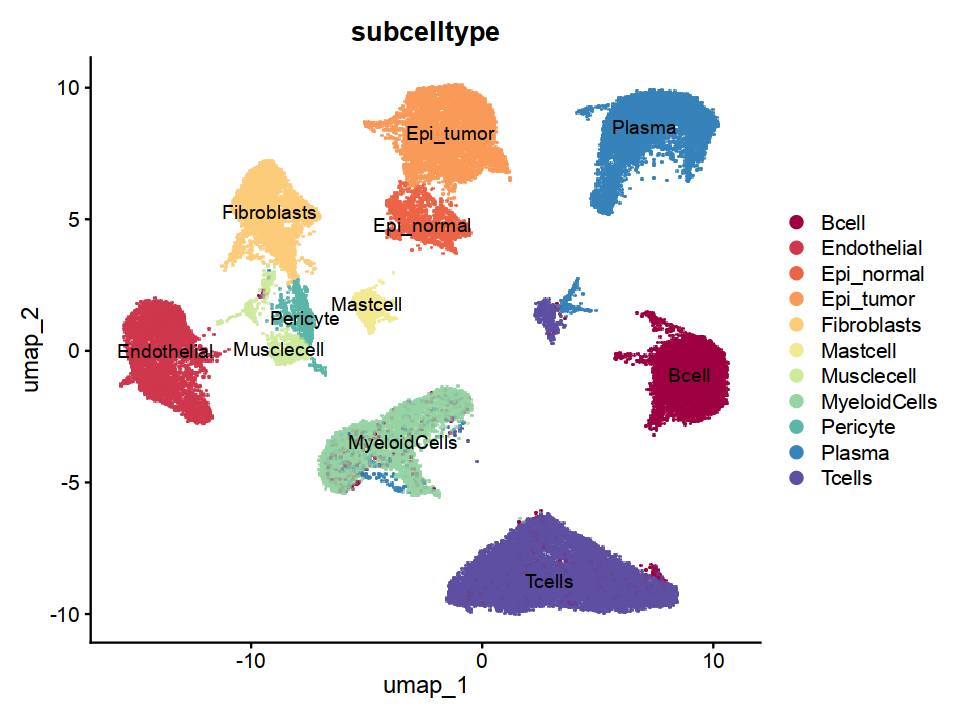

In [69]:
options(repr.plot.height=6,repr.plot.width=8)
pall

In [70]:
ggsave(filename = "UMAP_AllCelltypes.pdf",plot =pall ,width = 8,height = 8)

In [71]:
# Visualization
p_dim_split <- DimPlot(GCA_obj_subset_excludecells, reduction = "umap", group.by = c("subcelltype"),
                       raster = TRUE,pt.size = 2,split.by="sample",ncol=4,
                       cols = colorRampPalette(brewer.pal(10, "Spectral"))(11))

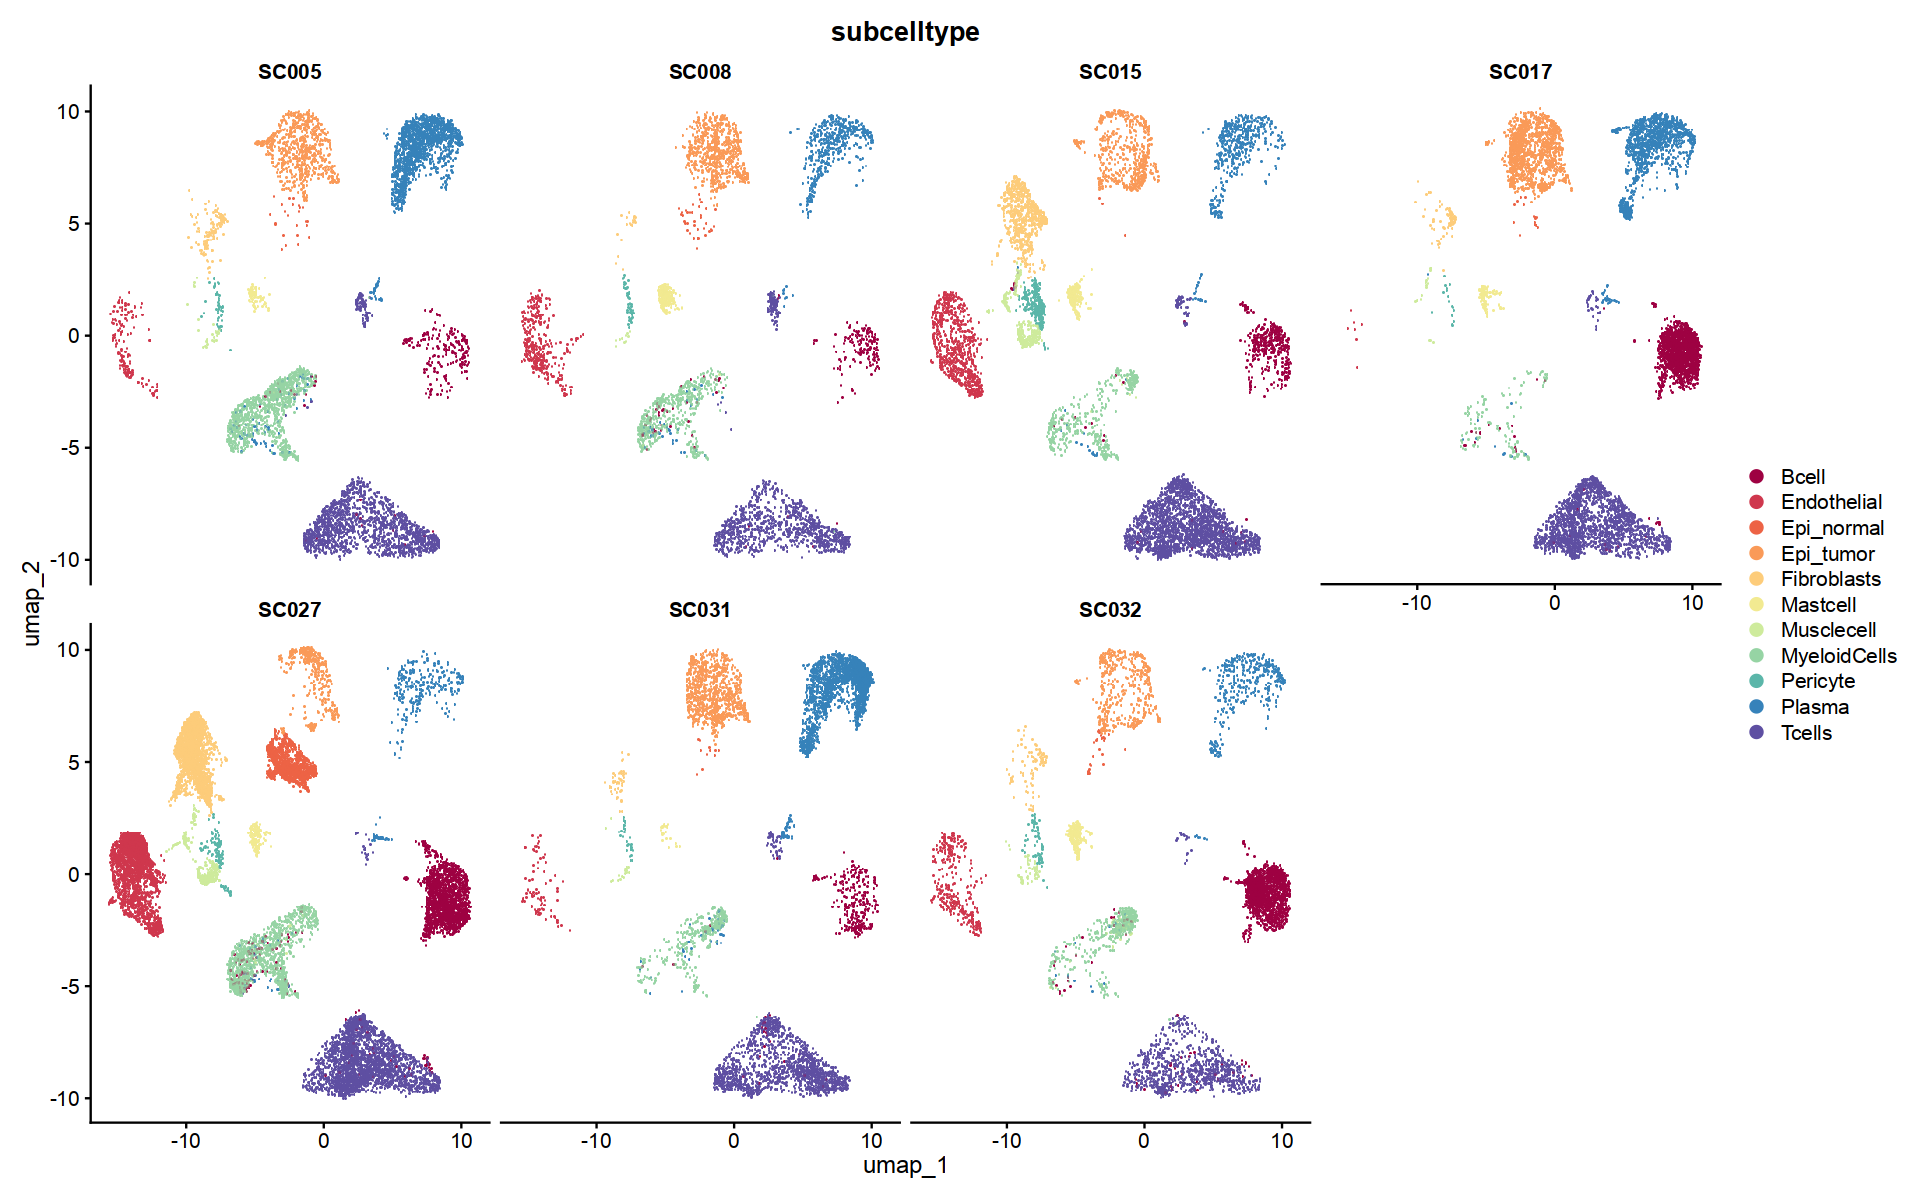

In [72]:
options(repr.plot.height=10,repr.plot.width=16)
p_dim_split

In [73]:
ggsave(filename = "UMAP_AllCelltypes.splitSample.pdf",plot =p_dim_split ,width = 10,height = 16)

### differential genes for all

In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
GCA_obj_subset_excludecells.markers <- FindAllMarkers(GCA_obj_subset_excludecells, only.pos = TRUE)

In [1292]:
GCA_obj_subset_excludecells.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) -> markersall

In [1457]:
for(i in markersall$cluster  %>% unique()){
    markersall  %>% filter(cluster==i)  %>% .[,'gene',drop=T] %>% head(n=10) -> genes
    cat("Cluster",i,':\t',genes,'\n')
}

Cluster Tcells :	 SKAP1 CD2 CD3D CD247 FYN CD3E BCL11B TRAC CD96 PTPRC 
Cluster Endothelial :	 CALCRL ADGRL4 LDB2 RAMP2 EMCN PTPRM ADAMTS9 SPARCL1 VWF ERG 
Cluster Plasma :	 MZB1 DERL3 TXNDC5 FKBP11 TNFRSF17 PIM2 IFNG-AS1 JSRP1 XBP1 TP53INP1 
Cluster MyeloidCells :	 TYROBP FCER1G AIF1 PLAUR BCL2A1 SLC8A1 IFI30 DOCK4 MS4A7 CXCL8 
Cluster Bcell :	 BANK1 MS4A1 AFF3 CD79A HLA-DQA1 RUBCNL CD37 LINC00926 BACH2 VPREB3 
Cluster Musclecell :	 MYL9 MYH11 TAGLN TPM2 ACTA2 PRKG1 CALD1 SOD3 C11orf96 SPARCL1 
Cluster Epi_tumor :	 ELF3 MUC1 TMC5 KRT18 KRT8 S100P KRT19 CLDN18 TSPAN8 MECOM 
Cluster Mastcell :	 CPA3 HPGDS TPSAB1 TPSB2 MS4A2 KIT SLC18A2 GATA2 SLC24A3 LTC4S 
Cluster Fabroblasts :	 COL1A2 DCN FBLN1 C1R C1S LUM COL6A2 SERPINF1 SERPING1 RBMS3 
Cluster Pericyte :	 RGS5 PRKG1 NOTCH3 CALD1 NDUFA4L2 PDGFRB CCDC102B LHFPL6 MYL9 PDE3A 
Cluster Epi_normal :	 KRT6A DSG3 LYPD3 KRT16 FGFBP1 SERPINB5 KRT17 TACSTD2 KRT6B RHCG 


In [53]:
genes <- c( 'BCL11B', 'CD2', 'CD3D',  ## Tcells
            'EMCN', 'ADGRL4', 'LDB2', ##Endothelial
            'MZB1', 'DERL3', 'FKBP11' , ### Plasma
           'PLAUR', 'CXCL8', 'AIF1' , ## MyeloidCells   
           'BANK1', 'MS4A1', 'BACH2',   ## Bcell
           'MYH11','TPM2', 'MYL9' , ## Musclecell
           'KRT8', 'MUC1', 'EPCAM',  ### Epi_tumor
           'KRT6A', 'DSG3', 'LYPD3', ## Epi_normal
           'CPA3', 'HPGDS', 'TPSAB1', ## Mastcell
            'DCN', 'FBLN1', ## Fabroblasts
           'RGS5', 'NOTCH3' ## Pericyte
          )

In [74]:
GCA_obj_subset_excludecells@meta.data$subcelltype  %>%  unique()

[1] "Tcells"       "Endothelial"  "Plasma"       "MyeloidCells" "Bcell"       
 [6] "Musclecell"   "Epi_tumor"    "Mastcell"     "Fibroblasts"  "Pericyte"    
[11] "Epi_normal"

In [75]:
GCA_obj_subset_excludecells@meta.data$subcelltype  <- factor(GCA_obj_subset_excludecells@meta.data$subcelltype,
                                                         levels = c('Tcells','Endothelial','Plasma','MyeloidCells',
                                                                    'Bcell', 'Musclecell','Epi_tumor','Epi_normal',
                                                                    'Mastcell','Fibroblasts','Pericyte'))

In [76]:
Idents(GCA_obj_subset_excludecells) <- 'subcelltype'

In [77]:
p_subset_excludecells <- DotPlot(GCA_obj_subset_excludecells, features = genes) + RotatedAxis()

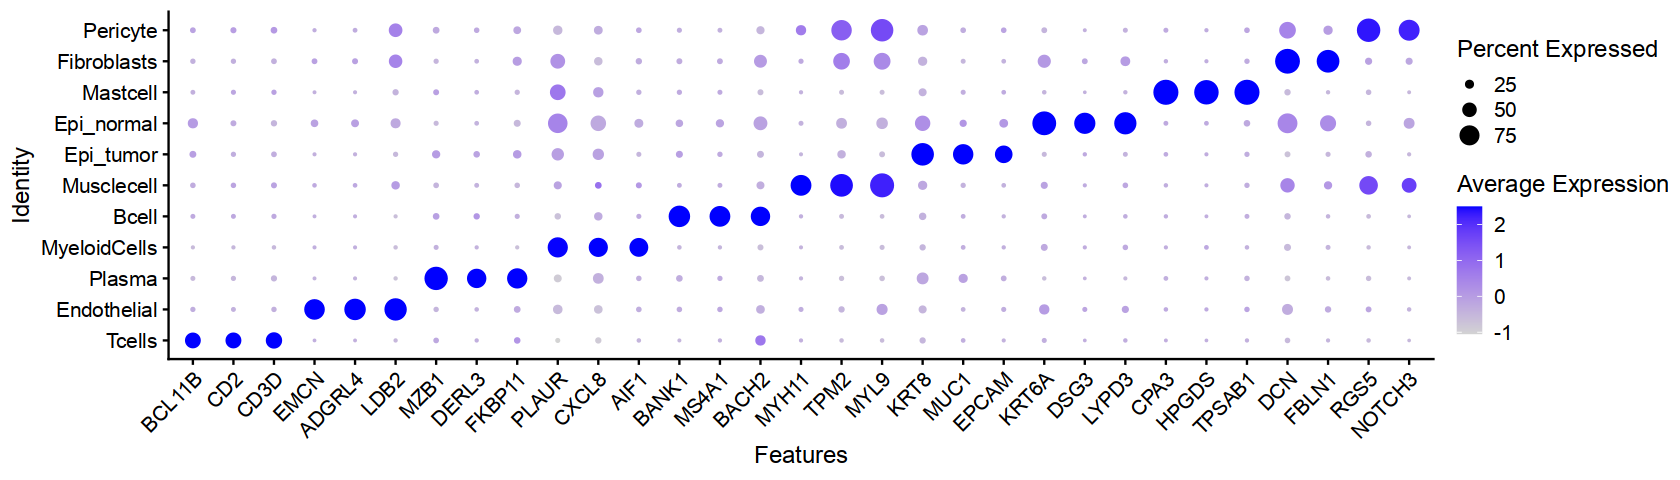

In [78]:
options(repr.plot.height=4,repr.plot.width=14)
p_subset_excludecells

In [79]:
ggsave(filename = "AllCelltypes.markergenes.pdf",plot =p_subset_excludecells ,width = 14,height = 4)

### distribution

In [80]:
library(tidyverse)

In [81]:
#GCA_obj_subset_excludecells <- readRDS('GCA_obj_subset_excludecells.Rds')

In [133]:
GCA_obj_subset_Tcell2 <-  readRDS(file = "GCA_obj_subset_Tcelltype.Rdata")

In [134]:
GCA_obj_subset_Tcell2@meta.data$newtypes  %>% as.character()  -> GCA_obj_subset_Tcell2@meta.data$newtypes 

In [136]:
GCA_obj_subset_Tcell2@meta.data  %>%  mutate(newtypes=ifelse(newtypes=='NK','NKcell',newtypes))  %>% 
                                      mutate(newtypes=ifelse(newtypes=='Tregs','Regulatory T',newtypes)) -> GCA_obj_subset_Tcell2@meta.data

In [138]:
saveRDS(GCA_obj_subset_Tcell2,file = "GCA_obj_subset_Tcelltype.Rdata")

In [83]:
GCA_obj_subset_Macrophage2 <- readRDS(,file = "GCA_obj_subset_Myloied.Rdata")

In [12]:
ERBB2_group <- read.table('../04.groupERBB2/ERBB2_7.txt',header=T)
ERBB2_group$sample <- rownames(ERBB2_group)

In [13]:
ERBB2_group$sample <- rownames(ERBB2_group)

In [14]:
ERBB2_group

,ERBB2,sample
,<dbl>,<chr>
SC008,0.805233,SC008
SC005,2.314381,SC005
SC027,3.860049,SC027
SC032,7.478490,SC032
SC017,7.827742,SC017
SC015,8.709902,SC015
SC031,9.204221,SC031


In [94]:
GCA_obj_subset_excludecells@meta.data -> metadata

In [95]:
#saveRDS(object = GCA_obj_subset_excludecells,file = "GCA_obj_subset_excludecells.Rds")

### for all celltypes

In [139]:
GCA_obj_subset_excludecells@meta.data$celltype  <- GCA_obj_subset_excludecells@meta.data$subcelltype 

In [4]:
GCA_obj_subset_excludecells@meta.data$celltype  %>% unique()

[1] "CD4+ T"         "Endothelial"    "Plasma"         "Regulatory T"  
 [5] "NKcell"         "Neutrophils"    "Bcell"          "CD8+ Low"      
 [9] "MacrophageM2"   "Musclecell"     "Epi_tumor"      "Monocytes"     
[13] "CD8+ T"         "MacrophageM1"   "Mastcell"       "DendriticCells"
[17] "Fibroblasts"    "Pericyte"       "Epi_normal"

In [6]:
GCA_obj_subset_excludecells@meta.data -> metadata

In [7]:
metadata$celltype <- as.character(metadata$celltype)

In [8]:
metadata$celltype  %>%  unique()

[1] "CD4+ T"         "Endothelial"    "Plasma"         "Regulatory T"  
 [5] "NKcell"         "Neutrophils"    "Bcell"          "CD8+ Low"      
 [9] "MacrophageM2"   "Musclecell"     "Epi_tumor"      "Monocytes"     
[13] "CD8+ T"         "MacrophageM1"   "Mastcell"       "DendriticCells"
[17] "Fibroblasts"    "Pericyte"       "Epi_normal"

In [301]:
#metadata[rownames(GCA_obj_subset_Macrophage2@meta.data),'celltype']  = GCA_obj_subset_Macrophage2@meta.data$newtypes  %>% as.character()

In [302]:
#metadata[rownames(GCA_obj_subset_Tcell2@meta.data),'celltype']  = GCA_obj_subset_Tcell2@meta.data$newtypes  %>% as.character()

In [145]:
#GCA_obj_subset_excludecells@meta.data <- metadata

In [147]:
#saveRDS(GCA_obj_subset_excludecells,file = "GCA_obj_subset_excludecells2.Rdata")

In [9]:
metadata %>% count(sample,celltype) -> sample_subcelltype_number

In [10]:
sample_subcelltype_number %>% group_by(sample) %>% 
    reframe(Percentage = n/sum(n),celltype = celltype)%>% as.data.frame() -> sample_subcelltype_number2

In [15]:
sample_subcelltype_number2$sample <-  factor(sample_subcelltype_number2$sample,levels = rownames(ERBB2_group))

In [16]:
right_join(sample_subcelltype_number2,ERBB2_group,by = "sample") -> sample_subcelltype_number2

In [17]:
sample_subcelltype_number2 %>% mutate(group = ifelse(ERBB2<7,"Low","High")) -> sample_subcelltype_number2_group

In [18]:
sample_subcelltype_number2_group$group  <- factor(sample_subcelltype_number2_group$group,levels=c('High',"Low"))

In [19]:
options(repr.plot.height=14,repr.plot.width=14)
p <- ggboxplot(sample_subcelltype_number2_group,x="group",y="Percentage",add="jitter",add.params=list(shape=21, fill="orange", size=3)
             )+geom_signif(comparisons = list(c("High","Low")),step_increase = 0.1,map_signif_level = F,
                           test = t.test)+ylab("Proportion") + 
            scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+facet_wrap(~celltype, scale="free")

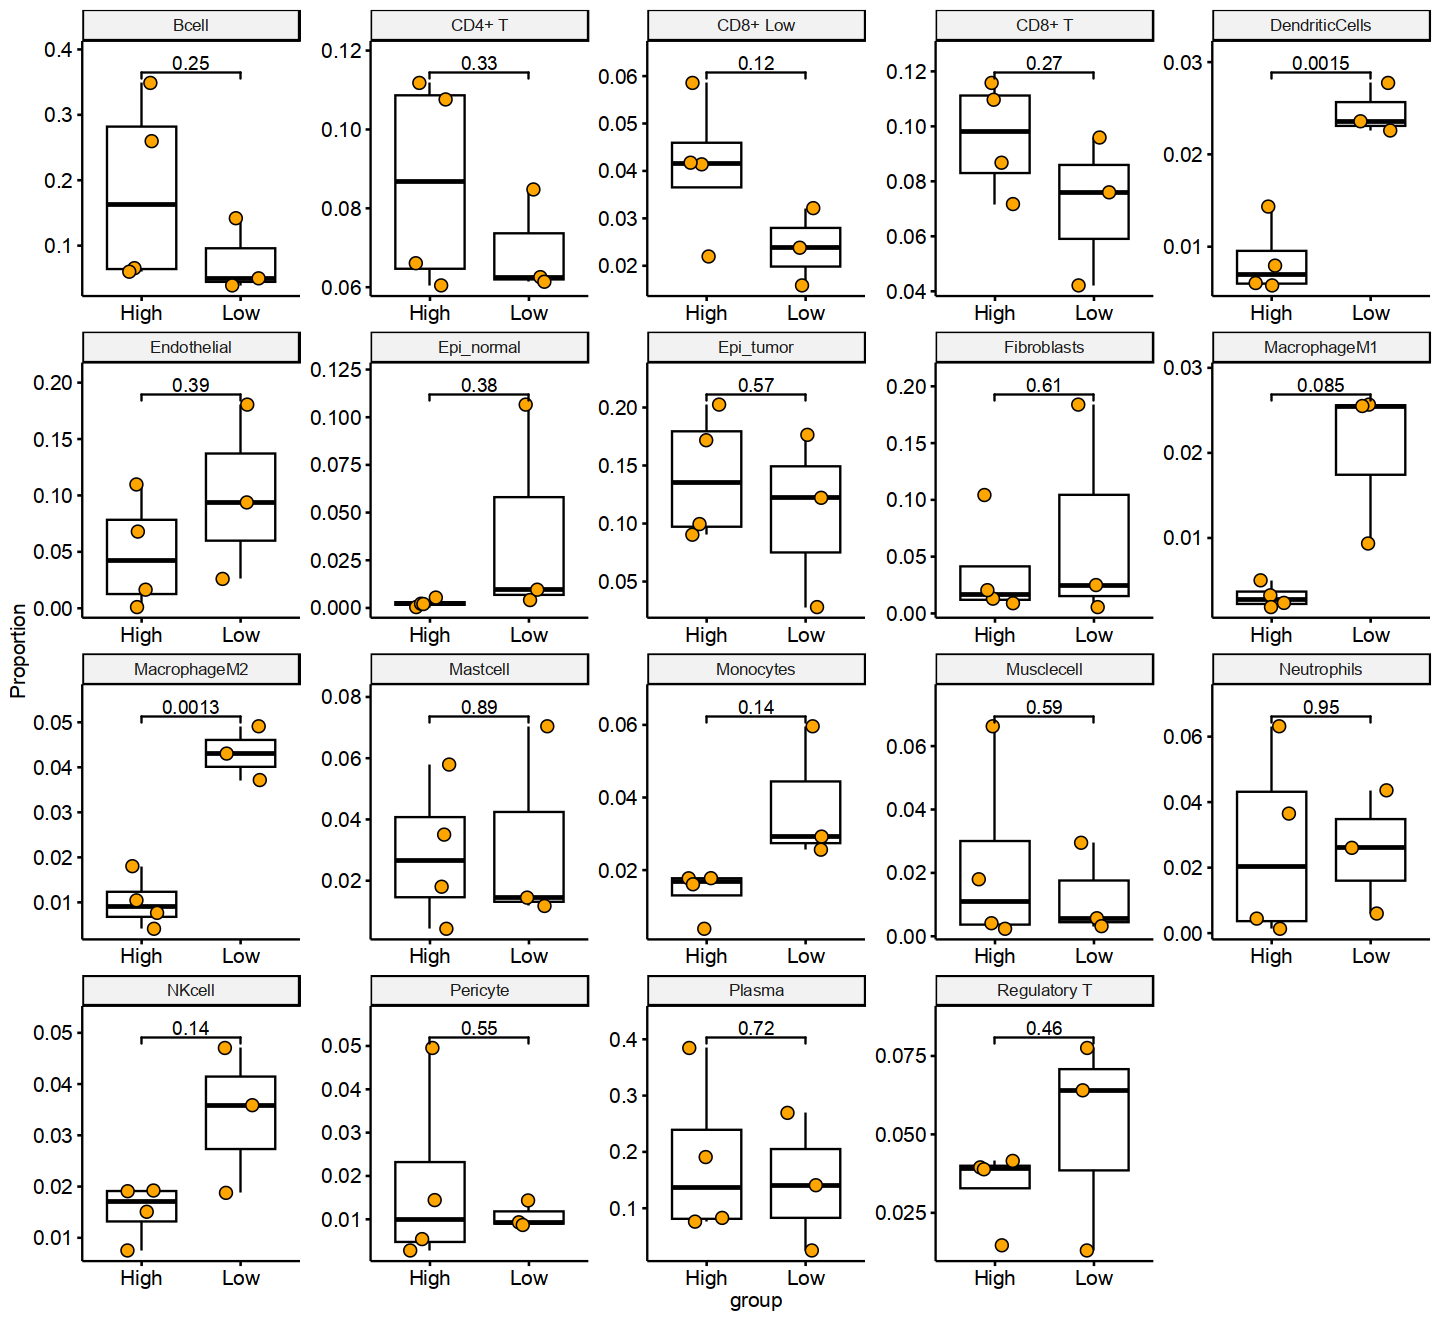

In [20]:
options(repr.plot.height=11,repr.plot.width=12)
p

In [21]:
ggsave(filename = "AllCelltypes.Box.pdf",plot = p, height = 11,width =12)

### for bar plot

In [315]:
metadata %>% count(sample,celltype) -> sample_subcelltype_number

In [316]:
sample_subcelltype_number %>% group_by(sample) %>% 
    reframe(Percentage = n/sum(n),celltype = celltype)%>% as.data.frame() -> sample_subcelltype_number2

In [317]:
sample_subcelltype_number2$sample <-  factor(sample_subcelltype_number2$sample,levels = rownames(ERBB2_group))

In [318]:
p_dis <- ggplot(sample_subcelltype_number2, aes(fill=celltype, y=Percentage, x=sample)) + theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'))+
    geom_bar(position="stack", stat="identity")

In [319]:
p_dis <- p_dis+ scale_fill_manual(values = colorRampPalette(brewer.pal(10, "Spectral"))(19))

In [320]:
#ggsave(filename = "AllMainCelltype_distri_barplot.pdf",plot = p_dis,height = 6,width = 8)

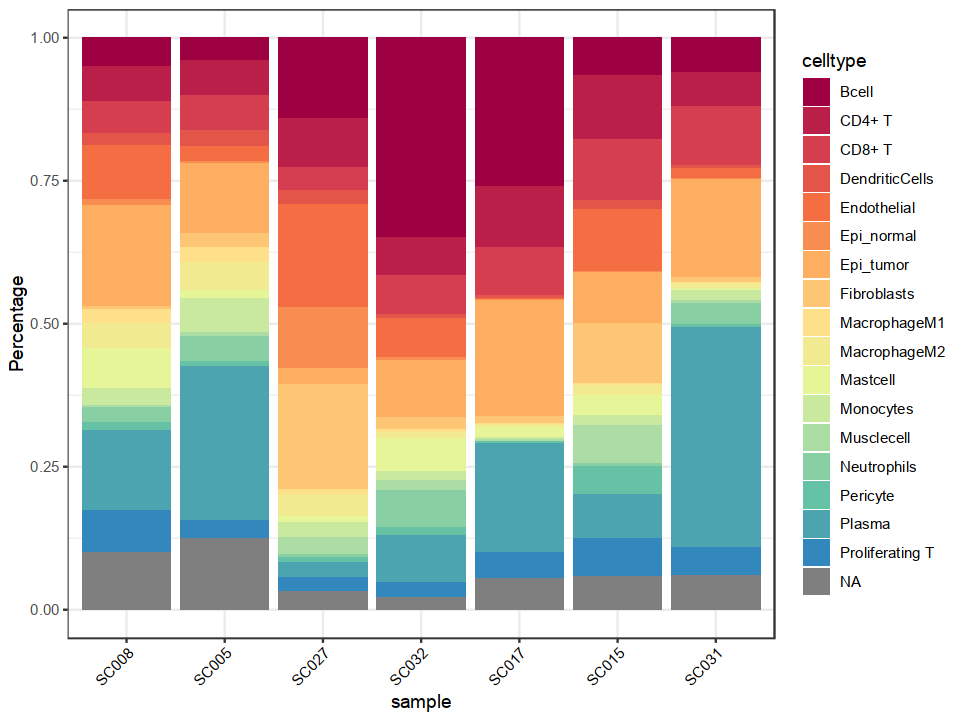

In [321]:
options(repr.plot.height=6,repr.plot.width=8)
p_dis

In [322]:
ggsave(filename = "AllMainCelltype_distri_barplot.pdf",plot = p_dis,height = 6,width = 8)